# Analyse de sentiments - Analyse exploratoire

### Table des matières

* [**1. Introduction**](#chapter1)
* [**2. Import des données**](#chapter2)
* [**3. Aperçu des données**](#chapter3)
* [**4. Valeurs manquantes**](#chapter4)
* [**5. Doublons**](#chapter5)
* [**6. Sélection des colonnes**](#chapter6)    
* [**7. Répartition des labels**](#chapter7)    
* [**8. Export des données**](#chapter8)    
* [**9. Conclusion**](#chapter9)    
    

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline



## 1 - Introduction <a class="anchor" id="chapter1"></a>

Ce notebook contient une analyse exploratoire des données du dataset sentiment140 en préalable à une analyse des sentiments des tweets contenus dans ce dataset.


## 2 - Import des données <a class="anchor" id="chapter2"></a>

In [4]:

data_path = "./sentiment140/"
datas = pd.read_csv(data_path + "training.1600000.processed.noemoticon.csv", delimiter=',', header=None, encoding = "ISO-8859-1")


## 3 - Aperçu des données <a class="anchor" id="chapter3"></a>

In [5]:
datas

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


Le fichier ne contient pas de titres, signification des colonnes:  
    - 0 : le label (0 : sentiment négatif, 4 : sentiment positif)  
    - 1 : l'id  
    - 2 : la date du tweet  
    - 3 : colonne non utilisée  
    - 4 : l'auteur du twwet  
    - 5 : le tweet  

## 4 - Valeurs manquantes <a class="anchor" id="chapter4"></a>

In [6]:
def table_valeurs_manquantes(df):
    valeurs_manquantes = ((df.isna().sum()/df.shape[0])*100).sort_values(ascending=False)  
    return pd.DataFrame(valeurs_manquantes,columns=['% de valeurs manquantes'])


In [7]:
table_valeurs_manquantes(datas)

,% de valeurs manquantes
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0


Aucune valeur manquante dans ce fichier.

## 5 - Doublons <a class="anchor" id="chapter5"></a>

In [8]:
datas.duplicated().value_counts()

False    1600000
dtype: int64

Aucune ligne complète en double.  

Contôle des doublons sur le tweet:

In [31]:
datas.duplicated(subset=[5]).value_counts()


False    1581466
True       18534
dtype: int64

Ces doublons sont à supprimer, le tweet sera la valeur d'entrée pour entrainer / évaluer les modèles.

In [32]:
datas = datas.drop_duplicates(subset=[5],keep='last')


## 6 - Sélection des colonnes <a class="anchor" id="chapter6"></a>

Valeurs en entrée : le tweet (colonne 5)  
Le label : le sentiment (colonne 0)  
Pour l'API azure cognitive services, un id doit être envoyé, l'id du tweet sera donc gardé (colonne 1)  

Sélection et renommage des colonnes:


In [35]:
datas = datas[[0, 1, 5]]
datas = datas.rename(columns={1: 'id' , 5: "text", 0: "label"})

In [36]:
datas

,label,id,text
0,0,1467810369,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,is upset that he can't update his Facebook by ...
2,0,1467810917,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,my whole body feels itchy and like its on fire
4,0,1467811193,"@nationwideclass no, it's not behaving at all...."
...,...,...,...
1599995,4,2193601966,Just woke up. Having no school is the best fee...
1599996,4,2193601969,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Happy 38th Birthday to my boo of alll time!!! ...


## 7 - Répartition des labels <a class="anchor" id="chapter7"></a>

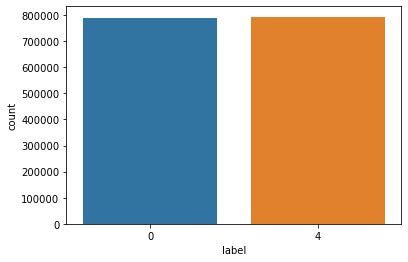

In [42]:
sns.countplot(data = datas, x="label")
plt.show()

Le jeu de données est équilibré.

## 8 - Export des données <a class="anchor" id="chapter8"></a>

In [46]:
datas.to_csv(data_path + "sentiment_datas_cleaned.csv", index=False)

## 9 - Conclusion <a class="anchor" id="chapter9"></a>

Le jeu de données est un jeu de données équilibré de sentiments positifs et négatifs.  
Il est nettoyé et prêt pour utilisation pour machine learning pour la prédiction de sentiments. 